# **Project: Providing data-driven suggestions for HR**

## Step 2. Feature Engineering and Encoding

This notebook focuses on:
- Creating new features (overworked)
- Dropping unnecessary columns
- Encoding categorical variables
- Preparing data for modeling


In [135]:
# Import data processing functions

from data_utils import load_cleaned_data, create_overworked_feature, encode_categorical_variables, get_data_summary

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# Load cleaned data from previous step
df1 = load_cleaned_data()
get_data_summary(df1)


Loading raw data...
Raw data shape: (14999, 10)
Cleaning data...
Data shape after cleaning: (11991, 10)
Removed 3008 duplicate rows

=== Data Summary ===
Shape: (11991, 10)
Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'left', 'promotion_last_5years', 'department', 'salary']
Missing values: 0
Duplicates: 0
Target distribution:
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


### Feature Engineering

We should always be cautious about data leakage, especially with high evaluation scores. Data leakage occurs when you use data in training that shouldn't be, either because it appears in the test data or wouldn't be available in production. It can lead to inflated model scores that don't reflect real-world performance.

Since satisfaction level might not be available for all employees and `average_monthly_hours` could be influenced by employees already planning to leave or being targeted for termination, it's important to address these issues.

For the next round of models, I suggest dropping `satisfaction_level` and adding a new binary feature called `overworked`, which will indicate whether an employee is likely overworked. This will help avoid data leakage and improve model accuracy.


In [123]:
# Apply feature engineering using the utility function
df2 = create_overworked_feature(df1)

# Display first few rows of new dataframe
df2.head()


Creating overworked feature...
Data shape after feature engineering: (11991, 9)


,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,department,salary,overworked
0,0.53,2,3,0,1,0,sales,low,0
1,0.86,5,6,0,1,0,sales,medium,1
2,0.88,7,4,0,1,0,sales,medium,1
3,0.87,5,5,0,1,0,sales,low,1
4,0.52,2,3,0,1,0,sales,low,0


In [124]:
# Check the overworked feature that was created
print('Overworked feature distribution:')
print(df2['overworked'].value_counts())
print('\nOverworked percentage:')
print(df2['overworked'].value_counts(normalize=True))


Overworked feature distribution:
overworked
1    7630
0    4361
Name: count, dtype: int64

Overworked percentage:
overworked
1    0.636311
0    0.363689
Name: proportion, dtype: float64


166.67 is approximately the average number of monthly hours for someone who works 50 weeks per year, 5 days per week, 8 hours per day. 

You could define being overworked as working more than 175 hours per month on average.

To make the `overworked` column binary, you could reassign the column using a boolean mask.
- `df3['overworked'] > 175` creates a series of booleans, consisting of `True` for every value > 175 and `False` for every values ≤ 175


In [125]:
# Display first few rows of the overworked column
df2['overworked'].head()


0    0
1    1
2    1
3    1
4    0
Name: overworked, dtype: int64

In [126]:
# Check the final shape after feature engineering
print("Data shape after feature engineering:")
print(df2.shape)
print("\nColumns after feature engineering:")
print(list(df2.columns))


Data shape after feature engineering:
(11991, 9)

Columns after feature engineering:
['last_evaluation', 'number_project', 'tenure', 'work_accident', 'left', 'promotion_last_5years', 'department', 'salary', 'overworked']


In [127]:
# Display first few rows of resulting dataframe after feature engineering
df2.head()


,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,department,salary,overworked
0,0.53,2,3,0,1,0,sales,low,0
1,0.86,5,6,0,1,0,sales,medium,1
2,0.88,7,4,0,1,0,sales,medium,1
3,0.87,5,5,0,1,0,sales,low,1
4,0.52,2,3,0,1,0,sales,low,0


### Categorical Variable Encoding

Now we need to encode the categorical variables for modeling:

- `department` and `salary` are categorical variables here
- `department` is a categorical variable, which means you can dummy it for modeling. 
- `salary` is categorical too, but it's ordinal. There's a hierarchy to the categories, so it's better not to dummy this column, but rather to convert the levels to numbers, 0–2.


In [ ]:

# Apply categorical encoding using the utility function
import  data_utils, importlib
# importlib.reload(data_utils)

df_enc = data_utils.encode_categorical_variables(df2)

Encoding categorical variables...
Encoded data shape: (11991, 18)


In [141]:
df_enc.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,overworked,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,6,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,4,0,1,0,1,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,5,0,1,0,0,1,False,False,False,False,False,False,False,True,False,False
4,0.52,2,3,0,1,0,0,0,False,False,False,False,False,False,False,True,False,False


In [156]:
# Save the encoded data
df_enc.to_pickle('../data/encoded_dataset.pkl')
print("Encoded data saved successfully!")

Encoded data saved successfully!


In [142]:
# Check the final shape and columns
print("Final encoded data shape:", df_enc.shape)
print("\nColumns:", list(df_enc.columns))
print("\nData types:")
print(df_enc.dtypes)


Final encoded data shape: (11991, 18)

Columns: ['last_evaluation', 'number_project', 'tenure', 'work_accident', 'left', 'promotion_last_5years', 'salary', 'overworked', 'department_IT', 'department_RandD', 'department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical']

Data types:
last_evaluation           float64
number_project              int64
tenure                      int64
work_accident               int64
left                        int64
promotion_last_5years       int64
salary                       int8
overworked                  int64
department_IT                bool
department_RandD             bool
department_accounting        bool
department_hr                bool
department_management        bool
department_marketing         bool
department_product_mng       bool
department_sales             bool
department_support           bool
department_technica

## Feature Engineering Complete!

The feature engineering and encoding process is now complete. The data is ready for modeling with:

- **Overworked feature created** (binary: >175 hours/month)
- **Data leakage prevention** (dropped `satisfaction_level` and `average_monthly_hours`)
- **Categorical encoding** (salary ordinal, department dummy encoded)
-  **Final encoded data** ready for machine learning models

**Next steps:** Proceed to the modeling notebooks (`03_baseline.ipynb`, `04_linear_regression_regularization.ipynb`, `05_XGBoost.ipynb`)


You could start by creating a stacked boxplot showing `average_monthly_hours` distributions for `number_project`, comparing the distributions of employees who stayed versus those who left.

Box plots are very useful in visualizing distributions within data, but they can be deceiving without the context of how big the sample sizes that they represent are. So, you could also plot a stacked histogram to visualize the distribution of `number_project` for those who stayed and those who left.


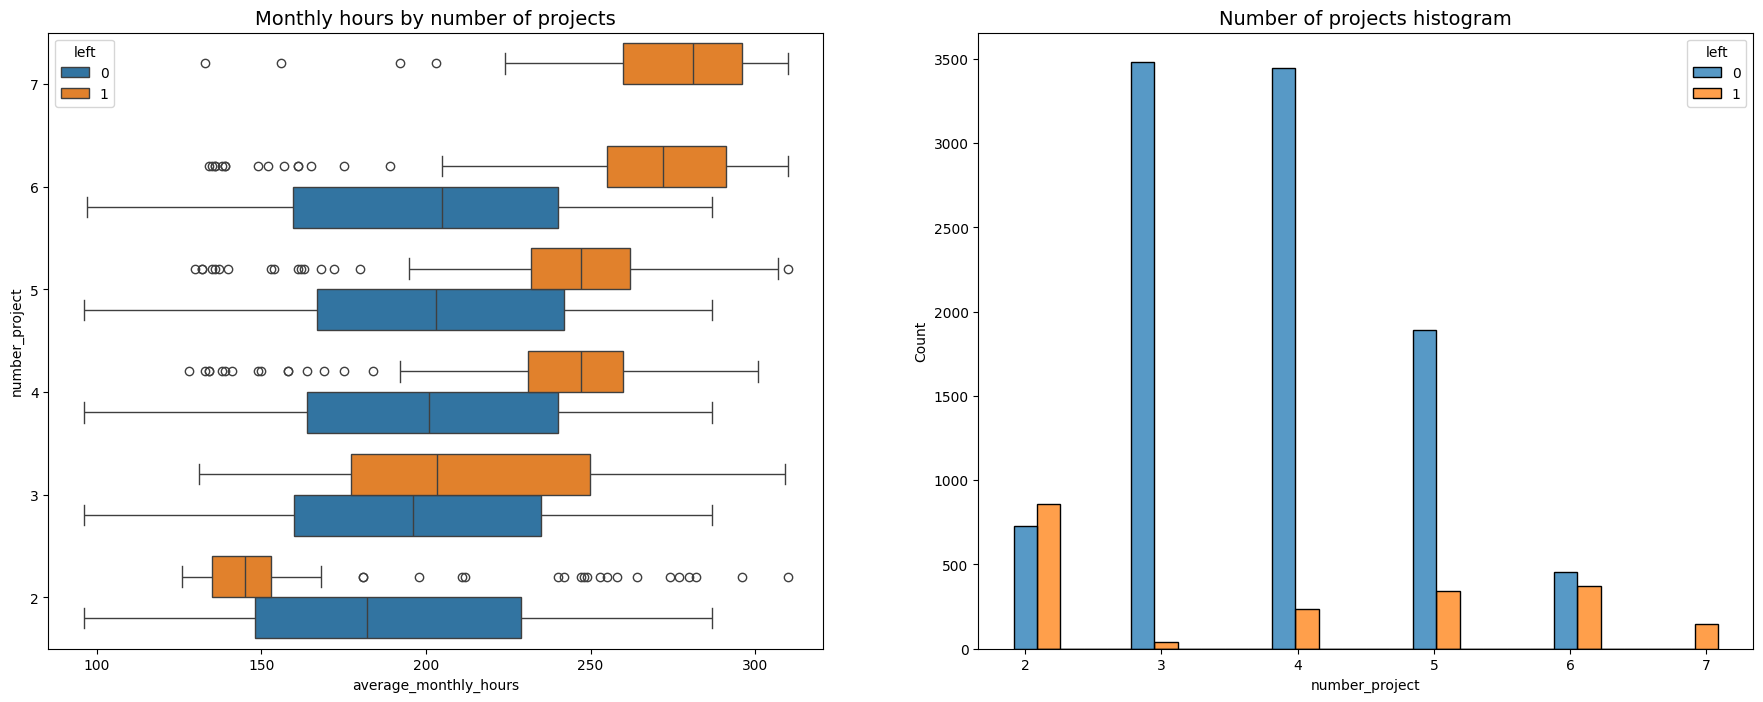

In [143]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Create histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

plt.show()


### Key Insights: Projects, Hours, and Attrition

- **All employees with 7 projects left** the company — This shows a strong indicator of overload.

- Two distinct high-risk attrition groups were identified:
  - **Group A(Who left company)**: Employees who worked **significantly fewer hours** than their peers — This is possibly fired or in process of leaving.

  - **Group B(Who don't left)**: Employees who worked **much longer hours** — This is likely burned out and voluntarily resigned.

- **Employees with 3–4 projects had the lowest attrition rate**. This suggesta an optimal workload.

- Based on a standard 40-hour workweek, the expected monthly workload is nearly 166 hours.  
  → **Most employees, including those who stayed, exceeded this — THis indicates widespread overwork**.


In [144]:
# Get value counts of stayed/left for employees with 7 projects
df1[df1['number_project']==7]['left'].value_counts()


left
1    145
Name: count, dtype: int64

This confirms that all employees with 7 projects did leave. 

Next, you could examine the average monthly hours versus the satisfaction levels.


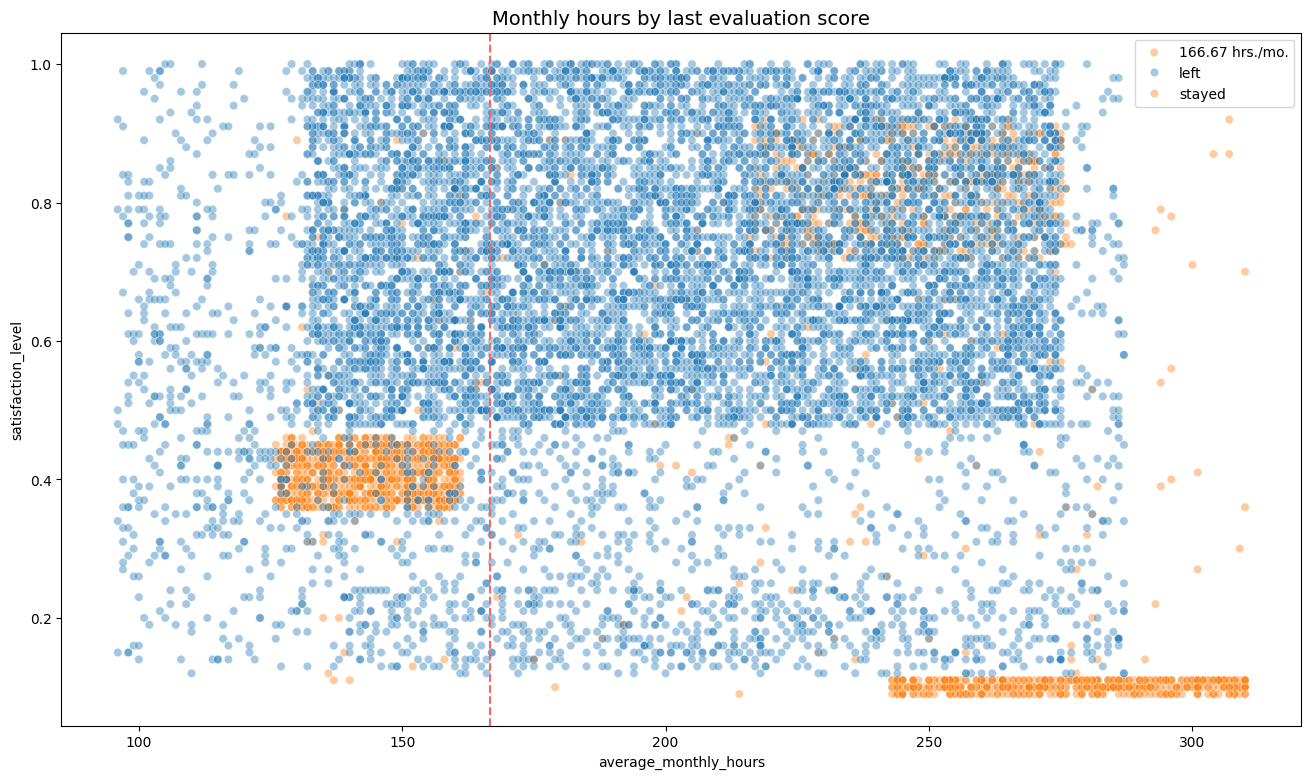

In [145]:
# Create scatterplot of `average_monthly_hours` versus `satisfaction_level`, comparing employees who stayed versus those who left
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');


- The scatterplot above shows that there was a sizeable group of employees who worked ~240–315 hours per month. 315 hours per month is over 75 hours per week for a whole year. It's likely this is related to their satisfaction levels being close to zero. 

- The plot also shows another group of people who left, those who had more normal working hours. Even so, their satisfaction was only around 0.4. It's difficult to speculate about why they might have left. 

- Finally, there is a group who worked ~210–280 hours per month, and they had satisfaction levels ranging ~0.7–0.9.


For the next visualization, it might be interesting to visualize satisfaction levels by tenure.


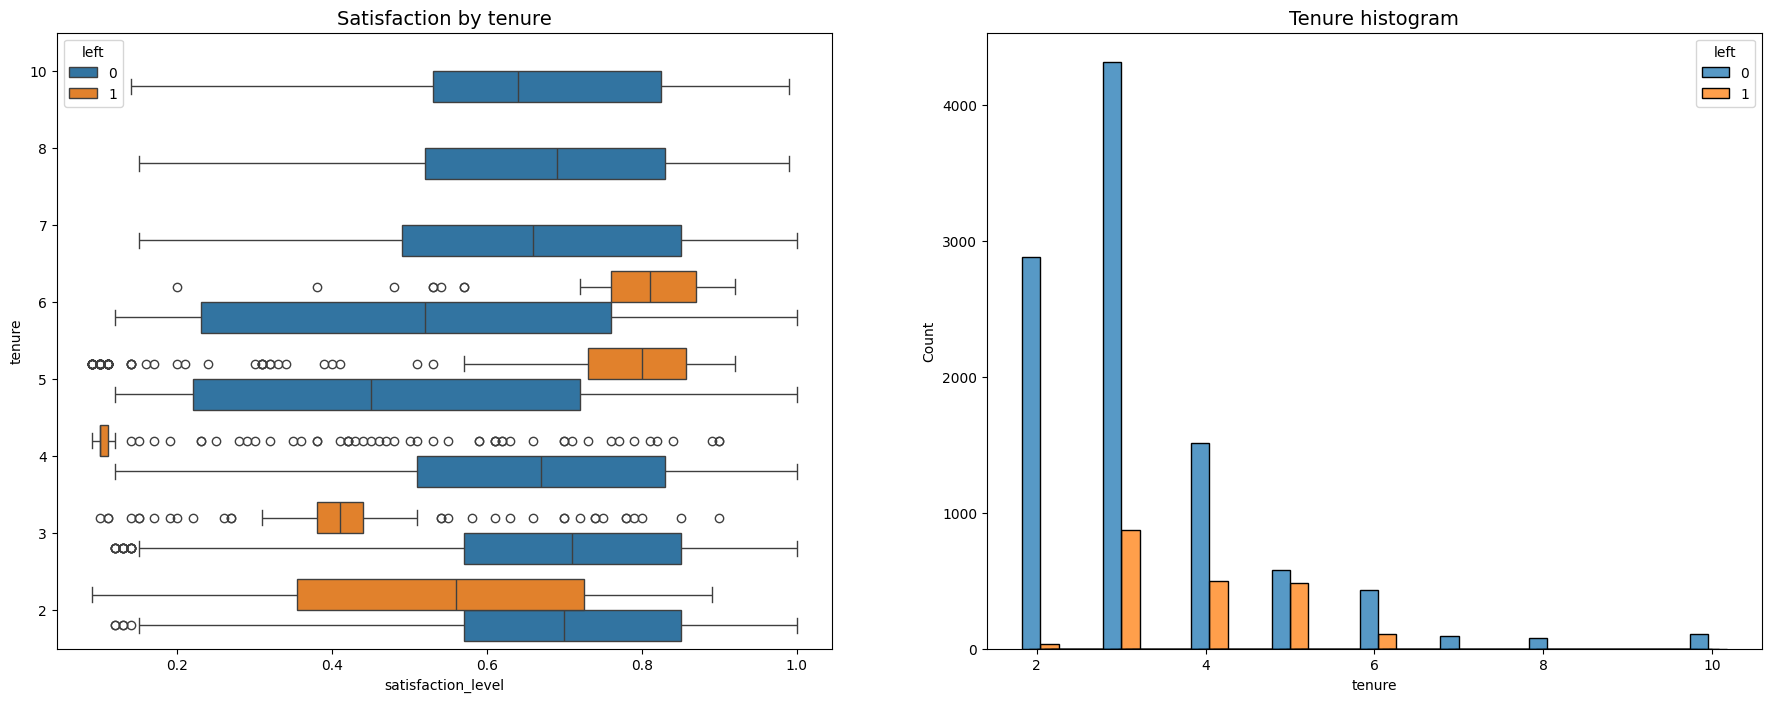

In [146]:
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing distributions of `satisfaction_level` by tenure, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')



# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')
plt.show();


There are many observations we could make from this plot.

- Employees who left fall into two general categories: dissatisfied employees with shorter tenures and very satisfied employees with medium-length tenures.
- Four-year employees who left seem to have an unusually low satisfaction level. It's worth investigating changes to company policy that might have affected people specifically at the four-year mark, if possible. 
- The longest-tenured employees didn't leave. Their satisfaction levels aligned with those of newer employees who stayed. 
- The histogram shows that there are relatively few longer-tenured employees. It's possible that they're the higher-ranking, higher-paid employees.


In [147]:
# Calculate mean and median satisfaction scores of employees who left and those who stayed
df1.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])


C:\Users\nirma\AppData\Local\Temp\ipykernel_19304\2160293746.py:2: FutureWarning: The provided callable <function mean at 0x000001DAD7BFEAC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df1.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])
C:\Users\nirma\AppData\Local\Temp\ipykernel_19304\2160293746.py:2: FutureWarning: The provided callable <function median at 0x000001DAD7D7D300> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df1.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])


,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


- As expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. 
- Interestingly, among employees who stayed, the mean satisfaction score appears to be slightly below the median score. This indicates that satisfaction levels among those who stayed might be skewed to the left.


### Examine of salary levels for different tenures.


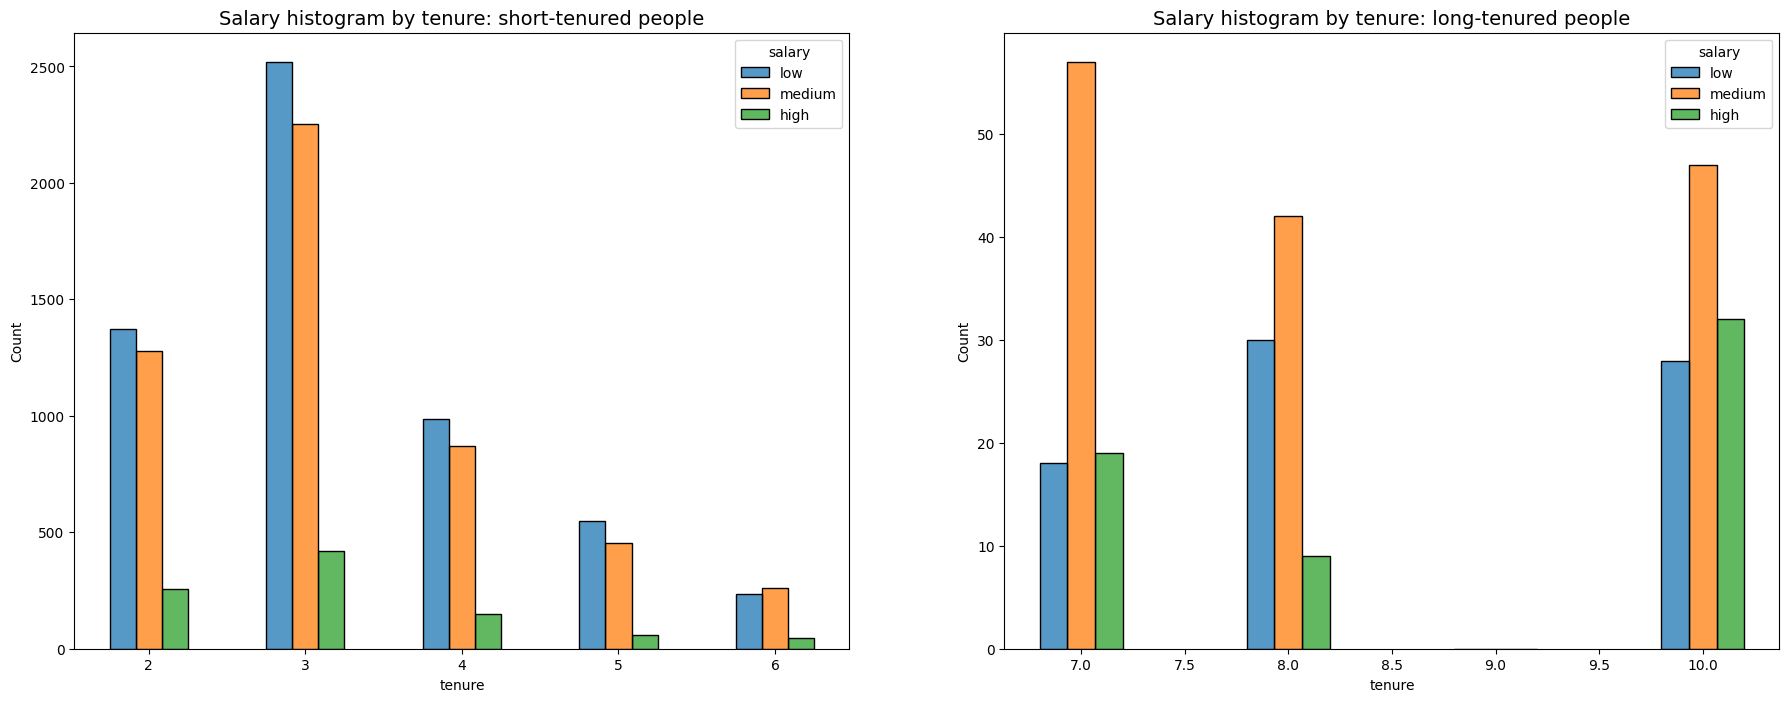

In [148]:
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Define short-tenured employees
tenure_short = df1[df1['tenure'] < 7]

# Define long-tenured employees
tenure_long = df1[df1['tenure'] > 6]

sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

# Plot long-tenured histogram
sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])

ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');


The plots above show that long-tenured employees were not disproportionately comprised of higher-paid employees.


### Scatter Plot(Correlation analysis)


Checking a correlation between working long hours and receiving high evaluation scores


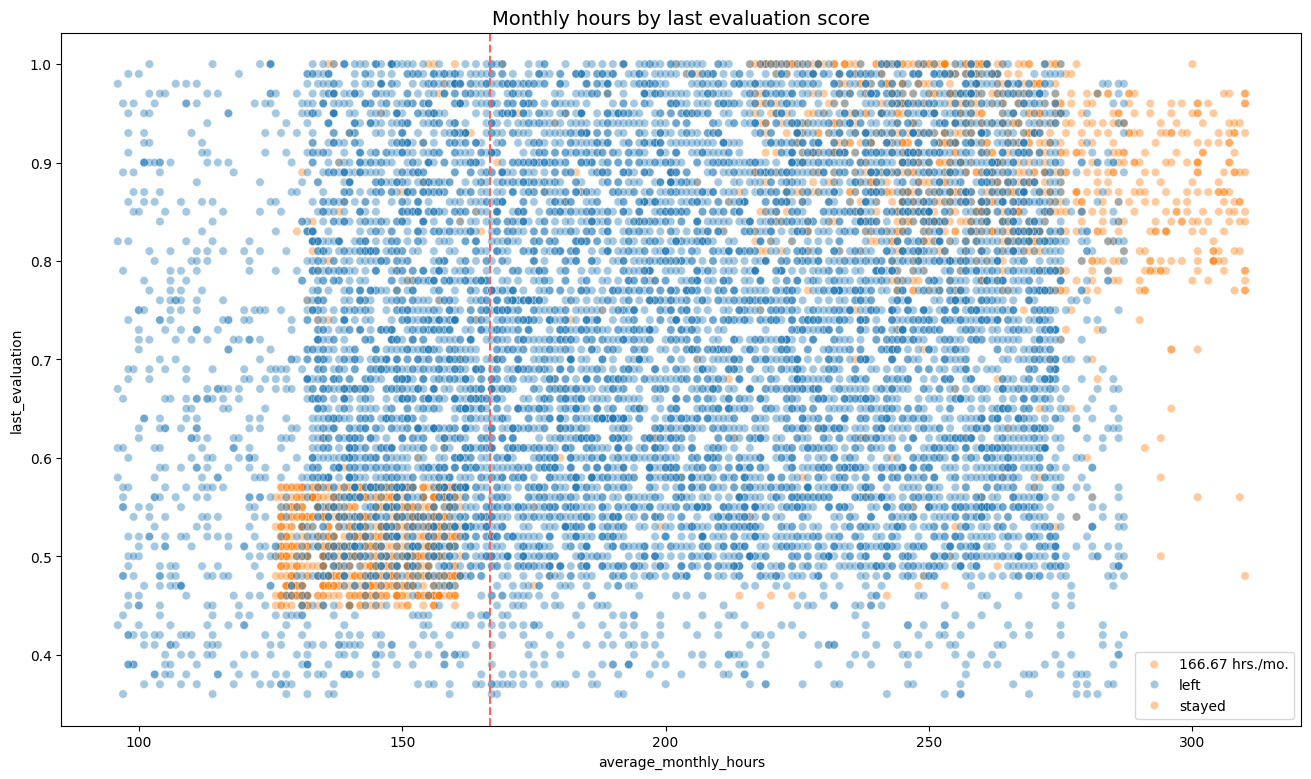

In [149]:
# Create scatterplot of `average_monthly_hours` versus `last_evaluation`
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');


The following observations can be made from the scatterplot above:
- The scatterplot indicates two groups of employees who left: overworked employees who performed very well and employees who worked slightly under the nominal monthly average of 166.67 hours with lower evaluation scores. 
- There seems to be a correlation between hours worked and evaluation score. 
- There isn't a high percentage of employees in the upper left quadrant of this plot; but working long hours doesn't guarantee a good evaluation score.
- Most of the employees in this company work well over 167 hours per month.


#### Examine whether employees who worked very long hours were promoted in the last five years.


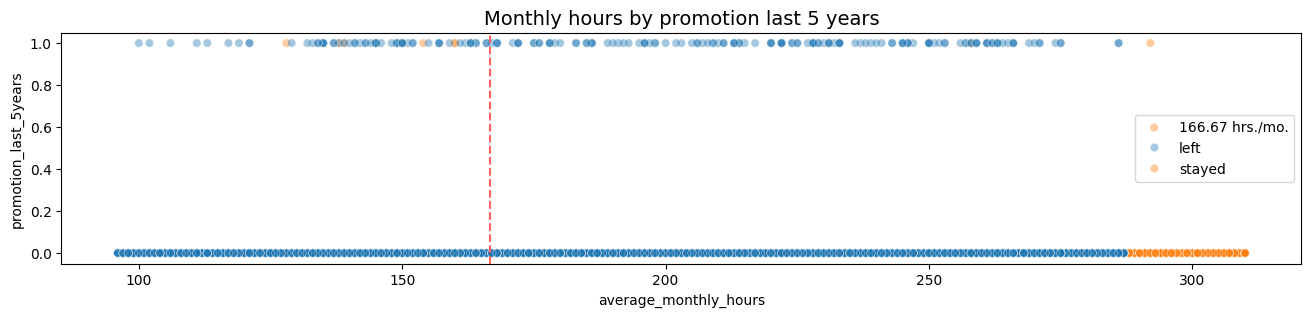

In [150]:
# Create plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14');


The plot above shows the following:
- very few employees who were promoted in the last five years left
- very few employees who worked the most hours were promoted
- all of the employees who left were working the longest hours


#### Examine how the employees who left are distributed across departments.


In [151]:
# Display counts for each department
df1["department"].value_counts()


department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

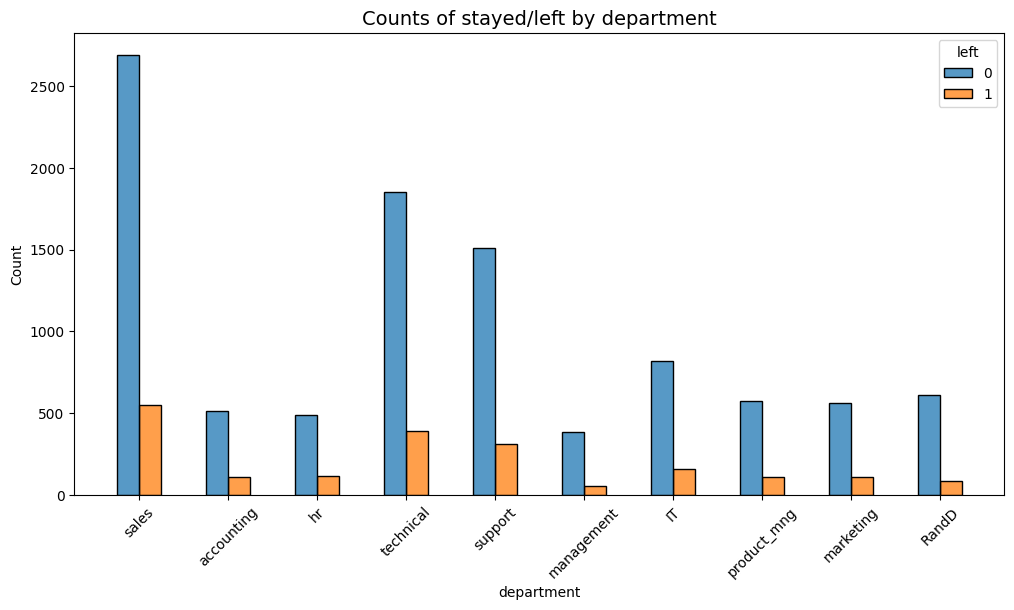

In [152]:
# Creating histogram to compare department distribution of employees who left to that of employees who didn't
plt.figure(figsize=(12,6))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation = 45)
plt.title('Counts of stayed/left by department', fontsize=14);


There doesn't seem to be any department that differs significantly in its proportion of employees who left to those who stayed. 

#### Lastly, checking for strong correlations between variables in the data.


In [153]:
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [154]:
# # Plot a correlation heatmap
# plt.figure(figsize=(16, 9))
# heatmap = sns.heatmap(df0.corr(), vmin=-1, vmax=1, annot=True, cmap='coolwarm')
# heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)


The correlation heatmap confirms that the number of projects, monthly hours, and evaluation scores all have some positive correlation with each other, and whether an employee leaves is negatively correlated with their satisfaction level.


### Insights From Analyse Phase


- It appears that employees are leaving the company as a result of poor management. 
- Leaving is tied to longer working hours, many projects, and generally lower satisfaction levels. 
- It can be ungratifying to work long hours and not receive promotions or good evaluation scores.
-  There's a sizeable group of employees at this company who are probably burned out. 
- It also appears that if an employee has spent more than six years at the company, they tend not to leave.
